#  Evaluation: Baseline, Point Forecasts, and TFT Probabilistic Forecasts

This notebook is designed for the presentation framing we discussed:

- **ARIMA/SARIMA** is shown first as a classical statistical baseline.
- **LSTM and Informer** are compared as the main point-forecasting deep learning models.
- **TFT** is shown as a different use case: uncertainty-aware forecasting with quantile bands and interpretability.
- TFT's `p50` median forecast is reported only as a reference point metric, not as the main head-to-head claim.

All plots are saved under `outputs/figures/` 


In [1]:
from pathlib import Path
import sys

sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

from src.evaluation.metrics import (
    compute_all_metrics,
    compute_tft_probabilistic_metrics,
    pinball_loss,
    TFT_QUANTILE_TAUS,
)

PREDS_DIR = Path('../outputs/predictions')
FIGS_DIR = Path('../outputs/figures')
FIGS_DIR.mkdir(parents=True, exist_ok=True)

VAL_START = pd.Timestamp('2016-03-28')
TEST_START = pd.Timestamp('2016-04-25')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.frameon': False,
})

COLORS = {
    'LSTM': '#4C78A8',
    'Informer': '#F58518',
    'TFT': '#54A24B',
    'Actual': '#222222',
}

print('Ready. Prediction directory:', PREDS_DIR.resolve())
print('Figure directory:', FIGS_DIR.resolve())


Ready. Prediction directory: /Users/dhruvyellanki/Downloads/Transformer-Based-Retail-Demand-Forecasting-Using-Time-Series-Data/outputs/predictions
Figure directory: /Users/dhruvyellanki/Downloads/Transformer-Based-Retail-Demand-Forecasting-Using-Time-Series-Data/outputs/figures


## 1. Load Saved Predictions

The loader normalizes all prediction files into the same structure: `id`, `date`, `actual`, `predicted`, `model`, and `split`.

For TFT, `predicted = p50`, because the median quantile is the fair point-forecast representation of the quantile model.

ARIMA is loaded as a separate baseline sample. The deep models are aligned to the TFT benchmark ids; ARIMA is intentionally **not** forced onto that slice because it was produced as a classical sample baseline.


In [2]:
PRED_FILES = {
    ('ARIMA', 'Validation'): PREDS_DIR / 'arima_val_preds.csv',
    ('ARIMA', 'Test'): PREDS_DIR / 'arima_test_preds.csv',
    ('LSTM', 'Validation'): PREDS_DIR / 'lstm_val_preds.csv',
    ('LSTM', 'Test'): PREDS_DIR / 'lstm_test_preds.csv',
    ('Informer', 'Validation'): PREDS_DIR / 'informer_val_preds.csv',
    ('Informer', 'Test'): PREDS_DIR / 'informer_test_preds.csv',
    ('TFT', 'Validation'): PREDS_DIR / 'tft_val_preds.csv',
    ('TFT', 'Test'): PREDS_DIR / 'tft_test_preds.csv',
}

DEEP_MODELS = {'LSTM', 'Informer', 'TFT'}


def split_start(split):
    return VAL_START if split == 'Validation' else TEST_START


def load_preds(model, split):
    path = PRED_FILES[(model, split)]
    if not path.exists():
        print(f'Missing: {path}')
        return None

    df = pd.read_csv(path)

    if 'p50' in df.columns and 'predicted' not in df.columns:
        df['predicted'] = df['p50']

    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
    elif 'step' in df.columns:
        df['date'] = split_start(split) + pd.to_timedelta(df['step'], unit='D')

    df['predicted'] = df['predicted'].clip(lower=0)
    df['actual'] = df['actual'].clip(lower=0)
    df['model'] = model
    df['split'] = split
    return df


preds = {key: load_preds(*key) for key in PRED_FILES}

id_path = PREDS_DIR / 'tft_train_sample_ids.txt'
if id_path.exists():
    benchmark_ids = {x for x in id_path.read_text().split() if x}
    print(f'Deep-model benchmark ids loaded: {len(benchmark_ids):,}')
else:
    benchmark_ids = None
    print('No benchmark id file found; using each deep-model prediction file as-is.')


def align_deep_model_to_benchmark(key, df):
    model, _ = key
    if df is None or benchmark_ids is None or model not in DEEP_MODELS:
        return df
    return df[df['id'].astype(str).isin(benchmark_ids)].copy()


preds = {key: align_deep_model_to_benchmark(key, df) for key, df in preds.items()}

row_counts = []
for (model, split), df in preds.items():
    row_counts.append({
        'Model': model,
        'Split': split,
        'Rows': 0 if df is None else len(df),
        'Series': 0 if df is None else df['id'].nunique(),
        'Evaluation role': 'Classical baseline sample' if model == 'ARIMA' else 'Aligned deep-model benchmark',
    })
row_counts = pd.DataFrame(row_counts)
display(row_counts)


Deep-model benchmark ids loaded: 5,000


,Model,Split,Rows,Series,Evaluation role
0,ARIMA,Validation,7028,251,Classical baseline sample
1,ARIMA,Test,7028,251,Classical baseline sample
2,LSTM,Validation,140000,5000,Aligned deep-model benchmark
3,LSTM,Test,140000,5000,Aligned deep-model benchmark
4,Informer,Validation,140000,5000,Aligned deep-model benchmark
5,Informer,Test,140000,5000,Aligned deep-model benchmark
6,TFT,Validation,140000,5000,Aligned deep-model benchmark
7,TFT,Test,140000,5000,Aligned deep-model benchmark


## 2. Metric Helper

This helper computes MAE, RMSE, and sMAPE consistently across baseline, point-forecast, and TFT reference tables.


In [3]:
def metrics_table(models, splits=('Validation', 'Test')):
    rows = []
    for model in models:
        for split in splits:
            df = preds.get((model, split))
            if df is None or df.empty:
                rows.append({'Model': model, 'Split': split, 'MAE': np.nan, 'RMSE': np.nan, 'sMAPE': np.nan})
                continue
            m = compute_all_metrics(df['actual'].to_numpy(), df['predicted'].to_numpy())
            rows.append({
                'Model': model,
                'Split': split,
                'MAE': round(m['MAE'], 4),
                'RMSE': round(m['RMSE'], 4),
                'sMAPE': round(m['sMAPE'], 4),
            })
    return pd.DataFrame(rows)


## 3. Classical Baseline: ARIMA/SARIMA

ARIMA/SARIMA is included as the first baseline because it is a transparent statistical forecasting method with explicit trend, autoregressive, moving-average, and seasonal components.

Use ARIMA to answer this baseline question:

> Before using deep learning, how well does a traditional per-series time-series model perform?

Important presentation caveat: ARIMA was evaluated on its own smaller sample because fitting per-series SARIMA models is computationally expensive. Therefore, these scores are useful as a **classical baseline reference**, not as a direct winner/loser comparison against the aligned 5,000-series LSTM/Informer/TFT benchmark.


,Model,Split,MAE,RMSE,sMAPE
0,ARIMA,Validation,1.5476,2.6603,108.6559
1,ARIMA,Test,1.5673,2.9428,108.1381


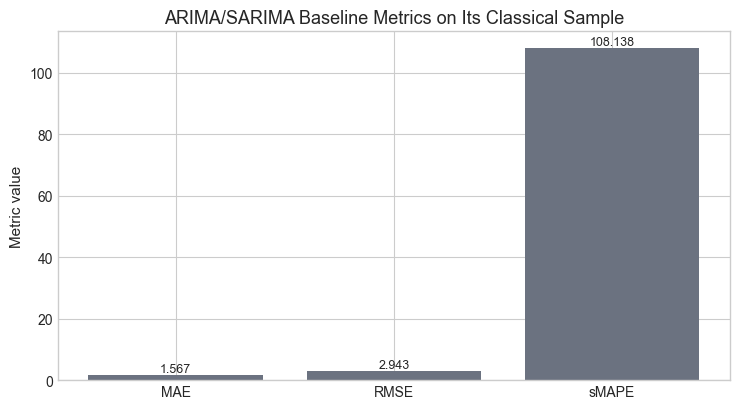

Saved: ../outputs/figures/presentation_arima_baseline_metrics.png


**How to present this:** ARIMA/SARIMA is the classical sanity-check baseline. It is not the main leaderboard because it was run on a smaller per-series sample, but it justifies that the project compared deep models against a traditional forecasting approach.

In [4]:
arima_metrics = metrics_table(['ARIMA'])
arima_metrics.to_csv(PREDS_DIR / 'presentation_arima_baseline_metrics.csv', index=False)

display(arima_metrics)

test_arima = arima_metrics[arima_metrics['Split'] == 'Test'].copy()
fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.bar(['MAE', 'RMSE', 'sMAPE'], test_arima[['MAE', 'RMSE', 'sMAPE']].iloc[0], color='#6B7280')
ax.set_title('ARIMA/SARIMA Baseline Metrics on Its Classical Sample')
ax.set_ylabel('Metric value')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h, f'{h:.3f}', ha='center', va='bottom', fontsize=9)
fig.tight_layout()
out = FIGS_DIR / 'presentation_arima_baseline_metrics.png'
fig.savefig(out, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', out)

display(Markdown(
    '**How to present this:** ARIMA/SARIMA is the classical sanity-check baseline. '
    'It is not the main leaderboard because it was run on a smaller per-series sample, '
    'but it justifies that the project compared deep models against a traditional forecasting approach.'
))


## 4. Main Point-Forecast Comparison: LSTM vs Informer

This is the clean head-to-head comparison because both models output a single point forecast and are evaluated on the same aligned 5,000-series benchmark.

TFT is intentionally excluded from the main point winner claim here. Its `p50` metrics are shown later as context only.


In [5]:
point_metrics = metrics_table(['LSTM', 'Informer'])
tft_p50_metrics = metrics_table(['TFT'])

point_metrics.to_csv(PREDS_DIR / 'presentation_point_metrics_lstm_informer.csv', index=False)
tft_p50_metrics.to_csv(PREDS_DIR / 'presentation_tft_p50_reference_metrics.csv', index=False)

print('Main point-forecast metrics:')
display(point_metrics)
print('TFT p50 reference metrics:')
display(tft_p50_metrics)


Main point-forecast metrics:


,Model,Split,MAE,RMSE,sMAPE
0,LSTM,Validation,1.1672,2.7354,152.1048
1,LSTM,Test,1.2055,2.8674,147.8799
2,Informer,Validation,1.1953,2.7497,145.9651
3,Informer,Test,1.2056,2.7442,141.8671


TFT p50 reference metrics:


,Model,Split,MAE,RMSE,sMAPE
0,TFT,Validation,1.4812,3.6761,159.2049
1,TFT,Test,1.3775,3.1287,157.7487


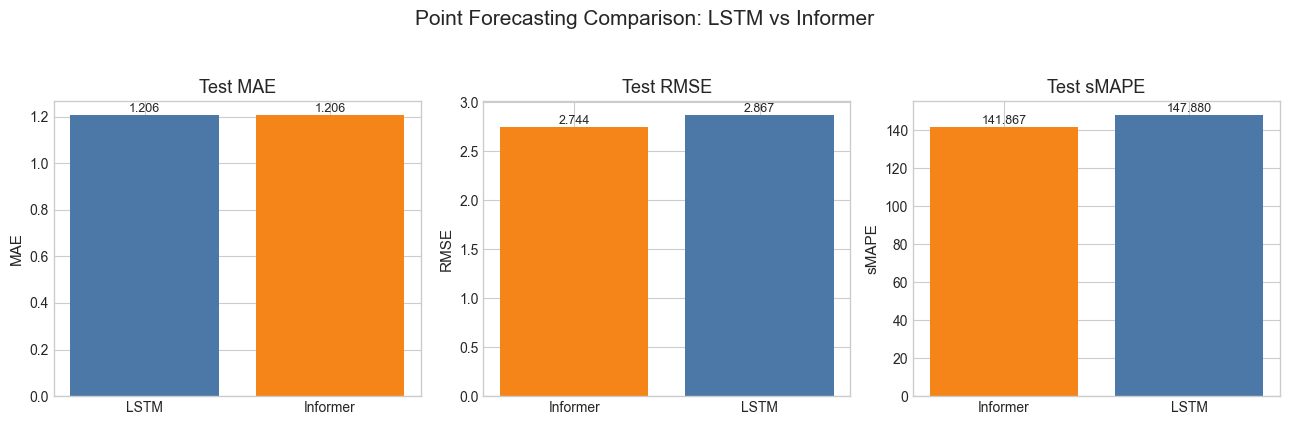

Saved: ../outputs/figures/presentation_point_metric_bars.png


In [6]:
test_point = point_metrics[point_metrics['Split'] == 'Test'].copy()
metrics = ['MAE', 'RMSE', 'sMAPE']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric in zip(axes, metrics):
    ordered = test_point.sort_values(metric)
    bars = ax.bar(ordered['Model'], ordered[metric], color=[COLORS[m] for m in ordered['Model']])
    ax.set_title(f'Test {metric}')
    ax.set_ylabel(metric)
    ax.set_xlabel('')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h, f'{h:.3f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Point Forecasting Comparison: LSTM vs Informer', y=1.05, fontsize=15)
fig.tight_layout()
out = FIGS_DIR / 'presentation_point_metric_bars.png'
fig.savefig(out, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', out)


## 5. Error Distribution and Category Breakdown

These plots help explain where the point models differ. The distribution plot shows absolute error behavior, while category plots separate FOODS, HOBBIES, and HOUSEHOLD.


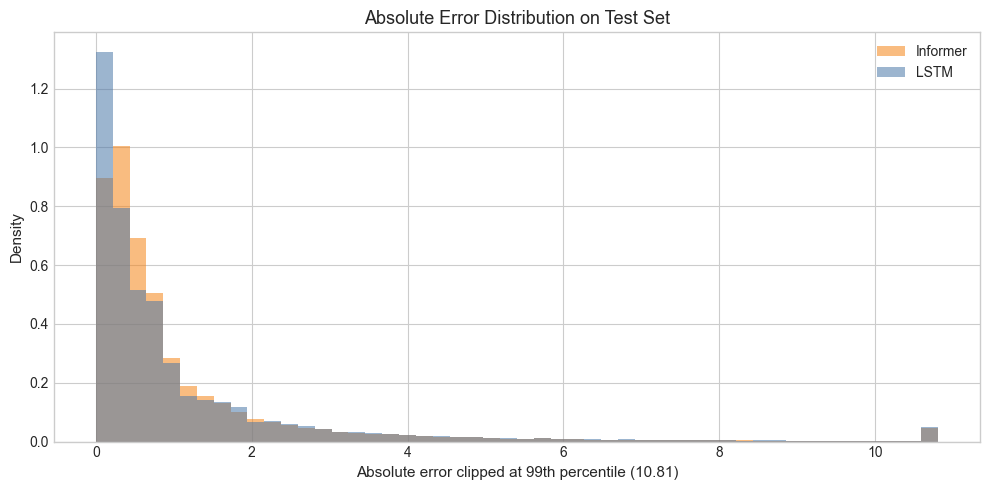

Saved: ../outputs/figures/presentation_point_abs_error_distribution.png


In [7]:
def m5_category_from_id(ids):
    s = ids.astype(str)
    return pd.Series(
        np.select(
            [s.str.startswith('FOODS'), s.str.startswith('HOBBIES'), s.str.startswith('HOUSEHOLD')],
            ['FOODS', 'HOBBIES', 'HOUSEHOLD'],
            default='OTHER',
        ),
        index=ids.index,
    )


def add_errors(df):
    work = df.copy()
    work['error'] = work['predicted'] - work['actual']
    work['abs_error'] = work['error'].abs()
    work['sq_error'] = work['error'] ** 2
    work['category'] = m5_category_from_id(work['id'])
    return work


point_test_frames = [add_errors(preds[(m, 'Test')]) for m in ['LSTM', 'Informer'] if preds[(m, 'Test')] is not None]
point_test = pd.concat(point_test_frames, ignore_index=True)

clip_at = point_test['abs_error'].quantile(0.99)
plot_data = point_test.copy()
plot_data['abs_error_clipped'] = plot_data['abs_error'].clip(upper=clip_at)

fig, ax = plt.subplots(figsize=(10, 5))
for model, g in plot_data.groupby('model'):
    ax.hist(g['abs_error_clipped'], bins=50, alpha=0.55, density=True, label=model, color=COLORS[model])
ax.set_title('Absolute Error Distribution on Test Set')
ax.set_xlabel(f'Absolute error clipped at 99th percentile ({clip_at:.2f})')
ax.set_ylabel('Density')
ax.legend()
fig.tight_layout()
out = FIGS_DIR / 'presentation_point_abs_error_distribution.png'
fig.savefig(out, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', out)


,Model,Category,MAE,RMSE,sMAPE,Rows
3,Informer,FOODS,1.6855,3.6822,127.0285,66080
0,LSTM,FOODS,1.7008,3.8404,132.5927,66080
4,Informer,HOBBIES,0.6516,1.2025,164.2955,26040
1,LSTM,HOBBIES,0.6158,1.2446,170.0414,26040
5,Informer,HOUSEHOLD,0.8447,1.5878,150.1483,47880
2,LSTM,HOUSEHOLD,0.8426,1.6862,156.9254,47880


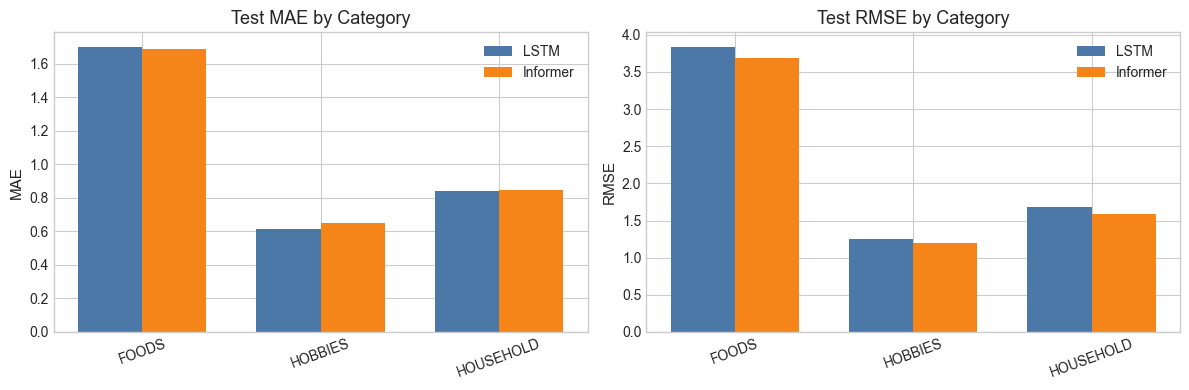

Saved: ../outputs/figures/presentation_point_category_metrics.png


In [8]:
category_rows = []
for model in ['LSTM', 'Informer']:
    df = add_errors(preds[(model, 'Test')])
    for category, g in df.groupby('category'):
        m = compute_all_metrics(g['actual'].to_numpy(), g['predicted'].to_numpy())
        category_rows.append({
            'Model': model,
            'Category': category,
            'MAE': round(m['MAE'], 4),
            'RMSE': round(m['RMSE'], 4),
            'sMAPE': round(m['sMAPE'], 4),
            'Rows': len(g),
        })

category_metrics = pd.DataFrame(category_rows).sort_values(['Category', 'Model'])
category_metrics.to_csv(PREDS_DIR / 'presentation_category_metrics_lstm_informer.csv', index=False)
display(category_metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for ax, metric in zip(axes, ['MAE', 'RMSE']):
    pivot = category_metrics.pivot(index='Category', columns='Model', values=metric).reindex(['FOODS', 'HOBBIES', 'HOUSEHOLD'])
    x = np.arange(len(pivot.index))
    width = 0.36
    ax.bar(x - width / 2, pivot['LSTM'], width, label='LSTM', color=COLORS['LSTM'])
    ax.bar(x + width / 2, pivot['Informer'], width, label='Informer', color=COLORS['Informer'])
    ax.set_title(f'Test {metric} by Category')
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=20)
    ax.set_ylabel(metric)
    ax.legend()

fig.tight_layout()
out = FIGS_DIR / 'presentation_point_category_metrics.png'
fig.savefig(out, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', out)


## 6. Forecast Overlays for Point Models

These plots are useful in the presentation because they show the actual 28-day forecast behavior instead of only aggregate metrics.


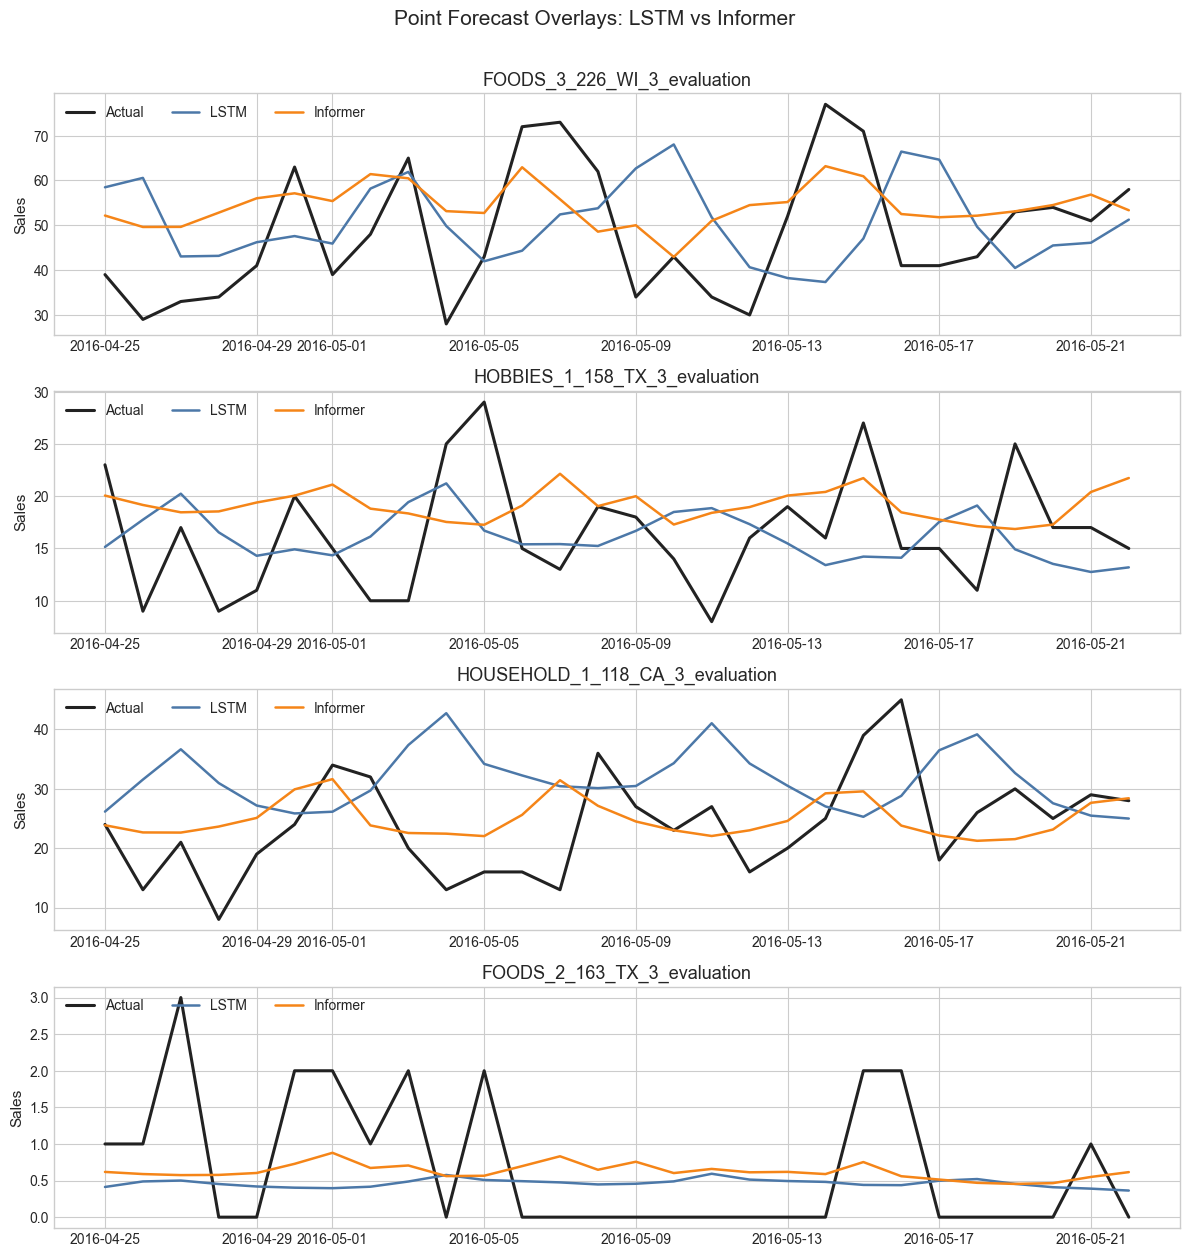

Saved: ../outputs/figures/presentation_point_forecast_overlays.png


In [9]:
def choose_representative_ids(df, n=4):
    stats = df.groupby('id')['actual'].agg(['mean', 'sum', 'max', 'std']).reset_index()
    stats = stats[stats['sum'] > 0].copy()
    picks = []

    for category_prefix in ['FOODS', 'HOBBIES', 'HOUSEHOLD']:
        cat = stats[stats['id'].str.startswith(category_prefix)]
        if cat.empty:
            continue
        picks.append(cat.sort_values(['sum', 'max'], ascending=False).iloc[0]['id'])

    remaining = stats[~stats['id'].isin(picks)].copy()
    if not remaining.empty:
        target = remaining['sum'].median()
        remaining['distance_to_median'] = (remaining['sum'] - target).abs()
        picks.append(remaining.sort_values('distance_to_median').iloc[0]['id'])

    return picks[:n]


lstm_test = preds[('LSTM', 'Test')]
informer_test = preds[('Informer', 'Test')]
selected_ids = choose_representative_ids(lstm_test, n=4)

fig, axes = plt.subplots(len(selected_ids), 1, figsize=(12, 3.1 * len(selected_ids)), sharex=False)
if len(selected_ids) == 1:
    axes = [axes]

for ax, series_id in zip(axes, selected_ids):
    base = lstm_test[lstm_test['id'] == series_id].sort_values('date')
    inf = informer_test[informer_test['id'] == series_id].sort_values('date')
    ax.plot(base['date'], base['actual'], color=COLORS['Actual'], linewidth=2.2, label='Actual')
    ax.plot(base['date'], base['predicted'], color=COLORS['LSTM'], linewidth=1.8, label='LSTM')
    ax.plot(inf['date'], inf['predicted'], color=COLORS['Informer'], linewidth=1.8, label='Informer')
    ax.set_title(series_id)
    ax.set_ylabel('Sales')
    ax.legend(loc='upper left', ncol=3)

fig.suptitle('Point Forecast Overlays: LSTM vs Informer', y=1.01, fontsize=15)
fig.tight_layout()
out = FIGS_DIR / 'presentation_point_forecast_overlays.png'
fig.savefig(out, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', out)


## 7. TFT as a Probabilistic Forecasting Model

TFT should be presented as an uncertainty-aware model. It outputs multiple quantiles (`p02`, `p10`, `p25`, `p50`, `p75`, `p90`, `p98`), so the key visuals are interval bands, coverage, width, pinball loss, and calibration.


In [10]:
tft_prob_rows = []
for split in ['Validation', 'Test']:
    df = preds[('TFT', split)]
    if df is None or df.empty:
        continue
    m = compute_tft_probabilistic_metrics(df)
    m['Split'] = split
    tft_prob_rows.append(m)

tft_prob_metrics = pd.DataFrame(tft_prob_rows)
tft_prob_metrics.to_csv(PREDS_DIR / 'presentation_tft_probabilistic_metrics.csv', index=False)
display(tft_prob_metrics)

coverage_note = ''
if not tft_prob_metrics.empty and 'empirical_coverage_p10_p90' in tft_prob_metrics.columns:
    test_cov = tft_prob_metrics.loc[tft_prob_metrics['Split'] == 'Test', 'empirical_coverage_p10_p90']
    if len(test_cov):
        coverage_note = f"Test P10-P90 empirical coverage: {float(test_cov.iloc[0]):.1%} vs target 80%."

display(Markdown(f'**Presentation note:** TFT provides uncertainty intervals. {coverage_note}'))


,n_rows,empirical_coverage_p10_p90,mean_width_p10_p90,nominal_interval_target,mean_pinloss_over_quantiles,Split
0,140000,0.4517,3.9605,0.8,0.3904,Validation
1,140000,0.4639,4.1783,0.8,0.3657,Test


**Presentation note:** TFT provides uncertainty intervals. Test P10-P90 empirical coverage: 46.4% vs target 80%.

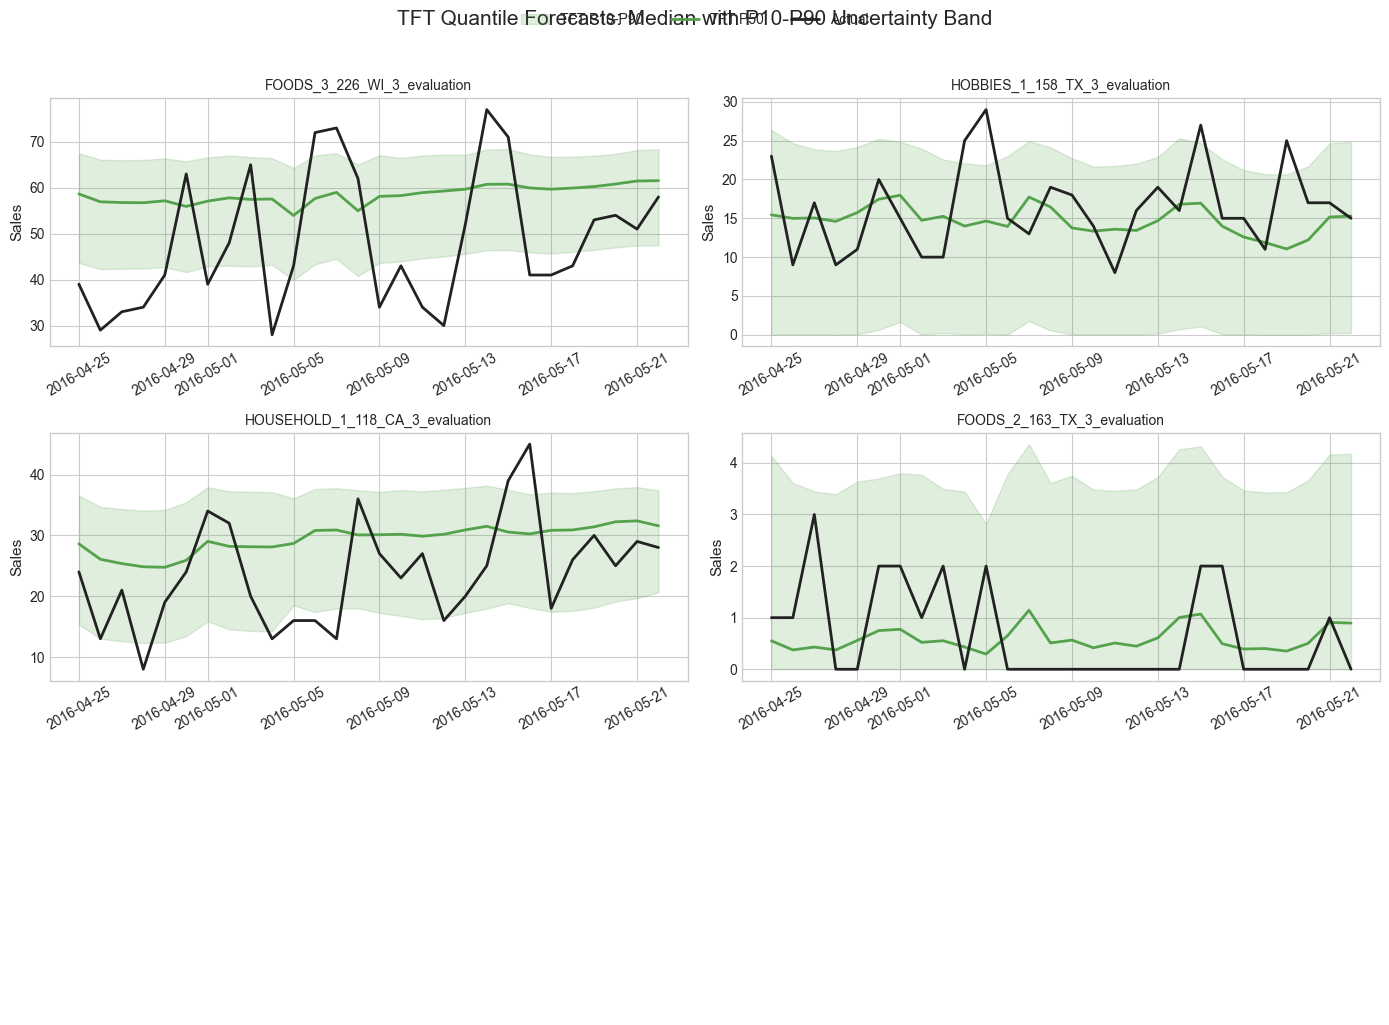

Saved: ../outputs/figures/presentation_tft_quantile_bands.png


In [11]:
tft_test = preds[('TFT', 'Test')].copy()
tft_test = tft_test.sort_values(['id', 'date'])
selected_tft_ids = choose_representative_ids(tft_test, n=6)

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=False)
axes = axes.ravel()
for ax, series_id in zip(axes, selected_tft_ids):
    g = tft_test[tft_test['id'] == series_id].sort_values('date')
    x = g['date']
    ax.fill_between(x, g['p10'], g['p90'], color=COLORS['TFT'], alpha=0.18, label='TFT P10-P90')
    ax.plot(x, g['p50'], color=COLORS['TFT'], linewidth=2.0, label='TFT P50')
    ax.plot(x, g['actual'], color=COLORS['Actual'], linewidth=2.0, label='Actual')
    ax.set_title(series_id, fontsize=10)
    ax.set_ylabel('Sales')
    ax.tick_params(axis='x', labelrotation=30)

for ax in axes[len(selected_tft_ids):]:
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3)
fig.suptitle('TFT Quantile Forecasts: Median with P10-P90 Uncertainty Band', y=1.02, fontsize=15)
fig.tight_layout()
out = FIGS_DIR / 'presentation_tft_quantile_bands.png'
fig.savefig(out, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', out)


/var/folders/fb/vkb3l76x1yqfw3hb3yqywwnc0000gn/T/ipykernel_21961/2678779167.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  horizon_summary['mae_p50'] = horizon.groupby('step').apply(lambda g: np.mean(np.abs(g['actual'] - g['p50']))).values


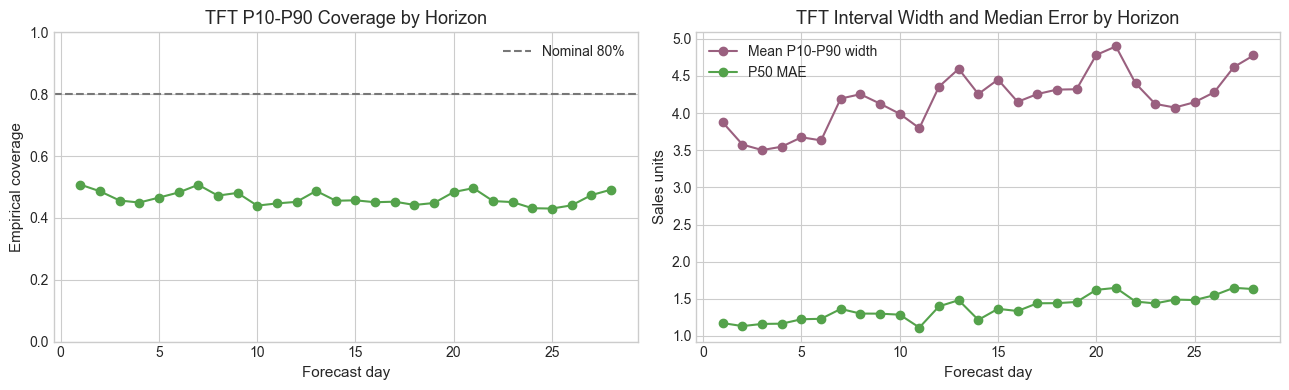

Saved: ../outputs/figures/presentation_tft_interval_diagnostics.png


In [12]:
# Coverage and interval width by forecast horizon.
horizon = tft_test.copy()
horizon['inside_p10_p90'] = ((horizon['actual'] >= horizon['p10']) & (horizon['actual'] <= horizon['p90'])).astype(float)
horizon['interval_width'] = horizon['p90'] - horizon['p10']
horizon_summary = horizon.groupby('step').agg(
    coverage=('inside_p10_p90', 'mean'),
    mean_width=('interval_width', 'mean'),
).reset_index()
horizon_summary['mae_p50'] = horizon.groupby('step').apply(lambda g: np.mean(np.abs(g['actual'] - g['p50']))).values

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(horizon_summary['step'] + 1, horizon_summary['coverage'], marker='o', color=COLORS['TFT'])
axes[0].axhline(0.80, color='#777777', linestyle='--', linewidth=1.5, label='Nominal 80%')
axes[0].set_ylim(0, 1)
axes[0].set_title('TFT P10-P90 Coverage by Horizon')
axes[0].set_xlabel('Forecast day')
axes[0].set_ylabel('Empirical coverage')
axes[0].legend()

axes[1].plot(horizon_summary['step'] + 1, horizon_summary['mean_width'], marker='o', color='#9A607F', label='Mean P10-P90 width')
axes[1].plot(horizon_summary['step'] + 1, horizon_summary['mae_p50'], marker='o', color=COLORS['TFT'], label='P50 MAE')
axes[1].set_title('TFT Interval Width and Median Error by Horizon')
axes[1].set_xlabel('Forecast day')
axes[1].set_ylabel('Sales units')
axes[1].legend()

fig.tight_layout()
out = FIGS_DIR / 'presentation_tft_interval_diagnostics.png'
fig.savefig(out, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', out)


,Split,Quantile,Tau,PinballLoss
0,Validation,p02,0.02,0.028426
1,Validation,p10,0.10,0.198851
2,Validation,p25,0.25,0.548662
3,Validation,p50,0.50,0.740608
4,Validation,p75,0.75,0.654634
5,Validation,p90,0.90,0.412274
6,Validation,p98,0.98,0.149309
7,Test,p02,0.02,0.029120
8,Test,p10,0.10,0.160993
9,Test,p25,0.25,0.469821


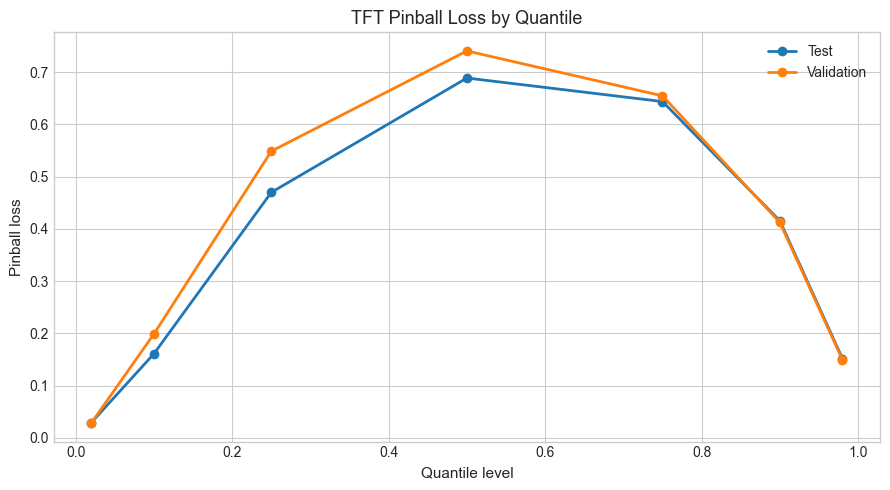

Saved: ../outputs/figures/presentation_tft_pinball_by_quantile.png


In [13]:
pinball_rows = []
for split in ['Validation', 'Test']:
    df = preds[('TFT', split)]
    if df is None:
        continue
    for col, tau in TFT_QUANTILE_TAUS.items():
        if col in df.columns:
            pinball_rows.append({
                'Split': split,
                'Quantile': col,
                'Tau': tau,
                'PinballLoss': pinball_loss(df['actual'].to_numpy(), df[col].clip(lower=0).to_numpy(), tau),
            })

pinball_df = pd.DataFrame(pinball_rows)
pinball_df.to_csv(PREDS_DIR / 'presentation_tft_pinball_by_quantile.csv', index=False)
display(pinball_df)

fig, ax = plt.subplots(figsize=(9, 5))
for split, g in pinball_df.groupby('Split'):
    ax.plot(g['Tau'], g['PinballLoss'], marker='o', linewidth=2, label=split)
ax.set_title('TFT Pinball Loss by Quantile')
ax.set_xlabel('Quantile level')
ax.set_ylabel('Pinball loss')
ax.legend()
fig.tight_layout()
out = FIGS_DIR / 'presentation_tft_pinball_by_quantile.png'
fig.savefig(out, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', out)


,Split,Tau,ObservedFrequency,Quantile
0,Validation,0.02,0.561150,p02
1,Validation,0.10,0.576193,p10
2,Validation,0.25,0.641871,p25
3,Validation,0.50,0.710179,p50
4,Validation,0.75,0.837471,p75
5,Validation,0.90,0.931036,p90
6,Validation,0.98,0.975850,p98
7,Test,0.02,0.540086,p02
8,Test,0.10,0.549814,p10
9,Test,0.25,0.616271,p25


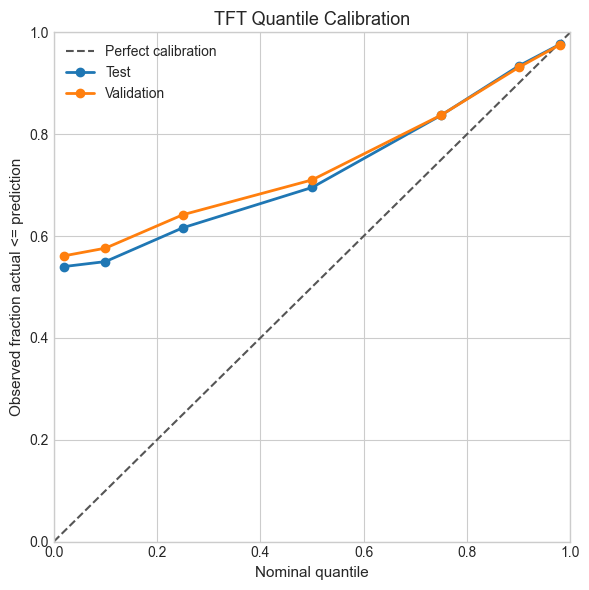

Saved: ../outputs/figures/presentation_tft_quantile_calibration.png


In [14]:
# Quantile calibration: for a calibrated quantile q_tau, actual <= q_tau should occur about tau of the time.
cal_rows = []
for split in ['Validation', 'Test']:
    df = preds[('TFT', split)]
    if df is None:
        continue
    for col, tau in TFT_QUANTILE_TAUS.items():
        if col in df.columns:
            observed = float((df['actual'] <= df[col].clip(lower=0)).mean())
            cal_rows.append({'Split': split, 'Tau': tau, 'ObservedFrequency': observed, 'Quantile': col})

cal_df = pd.DataFrame(cal_rows)
cal_df.to_csv(PREDS_DIR / 'presentation_tft_quantile_calibration.csv', index=False)
display(cal_df)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], color='#555555', linestyle='--', linewidth=1.5, label='Perfect calibration')
for split, g in cal_df.groupby('Split'):
    ax.plot(g['Tau'], g['ObservedFrequency'], marker='o', linewidth=2, label=split)
ax.set_title('TFT Quantile Calibration')
ax.set_xlabel('Nominal quantile')
ax.set_ylabel('Observed fraction actual <= prediction')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()
out = FIGS_DIR / 'presentation_tft_quantile_calibration.png'
fig.savefig(out, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', out)


### TFT Probabilistic Forecast (Quantile Bands)

Visualizing the predicted 10-90% and 25-75% uncertainty intervals for a sample series over the test horizon.

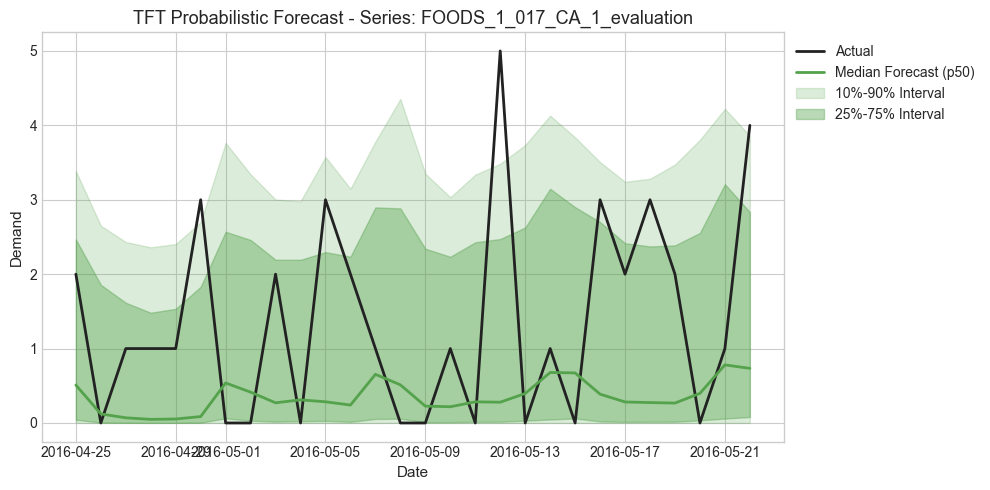

Saved: ../outputs/figures/presentation_tft_quantile_bands.png


In [15]:
df_test = preds[('TFT', 'Test')]
if df_test is not None:
    sample_id = df_test['id'].unique()[0]
    plot_df = df_test[df_test['id'] == sample_id].sort_values('date')
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(plot_df['date'], plot_df['actual'], label='Actual', color=COLORS['Actual'], linewidth=2)
    ax.plot(plot_df['date'], plot_df['p50'], label='Median Forecast (p50)', color=COLORS['TFT'], linewidth=2)
    
    if 'p10' in plot_df.columns and 'p90' in plot_df.columns:
        ax.fill_between(plot_df['date'], plot_df['p10'], plot_df['p90'], color=COLORS['TFT'], alpha=0.2, label='10%-90% Interval')
    if 'p25' in plot_df.columns and 'p75' in plot_df.columns:
        ax.fill_between(plot_df['date'], plot_df['p25'], plot_df['p75'], color=COLORS['TFT'], alpha=0.4, label='25%-75% Interval')
    
    ax.set_title(f'TFT Probabilistic Forecast - Series: {sample_id}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Demand')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    fig.tight_layout()
    
    out = FIGS_DIR / 'presentation_tft_quantile_bands.png'
    fig.savefig(out, dpi=160, bbox_inches='tight')
    plt.show()
    print('Saved:', out)


## 8. TFT Interpretability Figures

The project already generates TFT interpretability artifacts. Use these as a separate slide after the uncertainty slides.


### Static variable importance

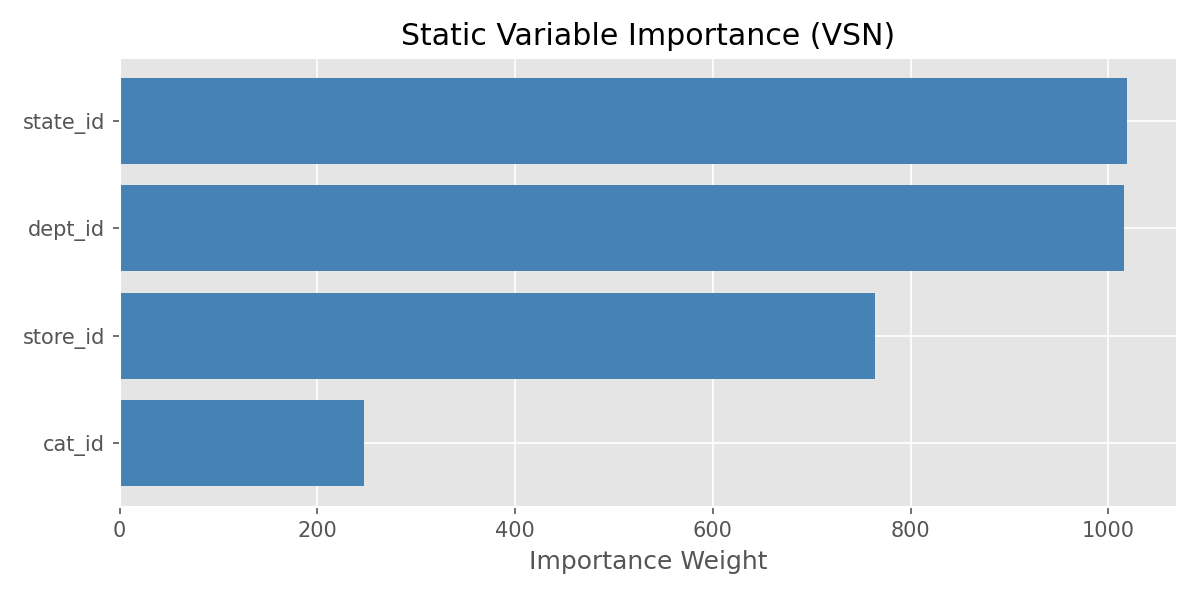

### Encoder variable importance

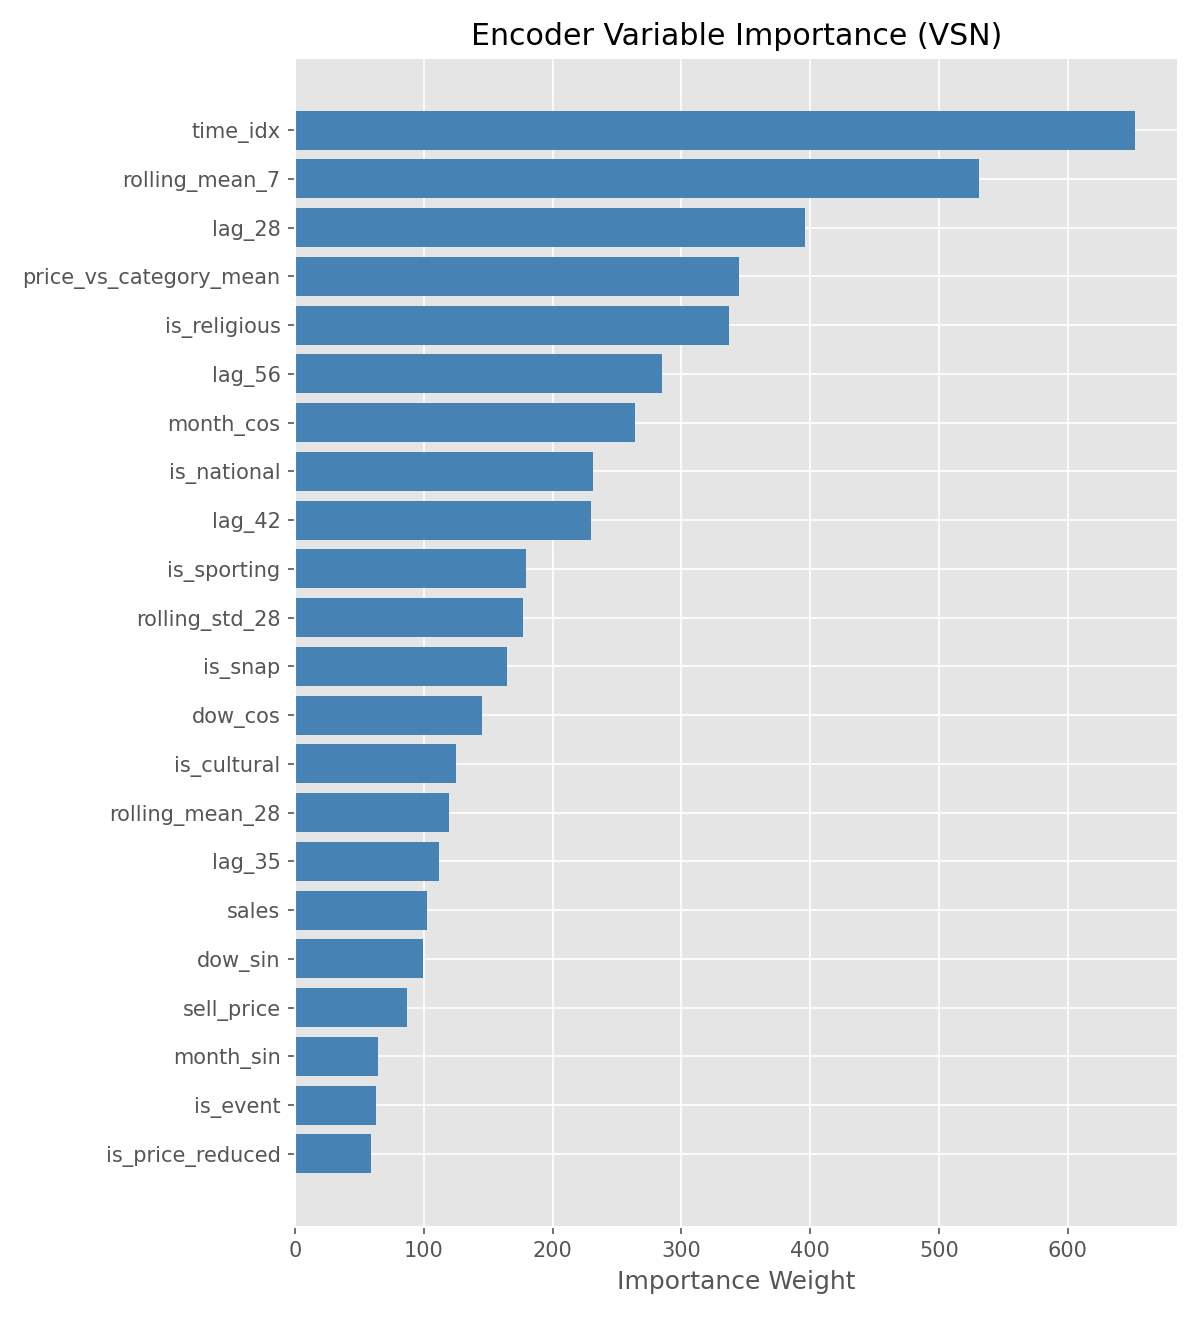

### Decoder variable importance

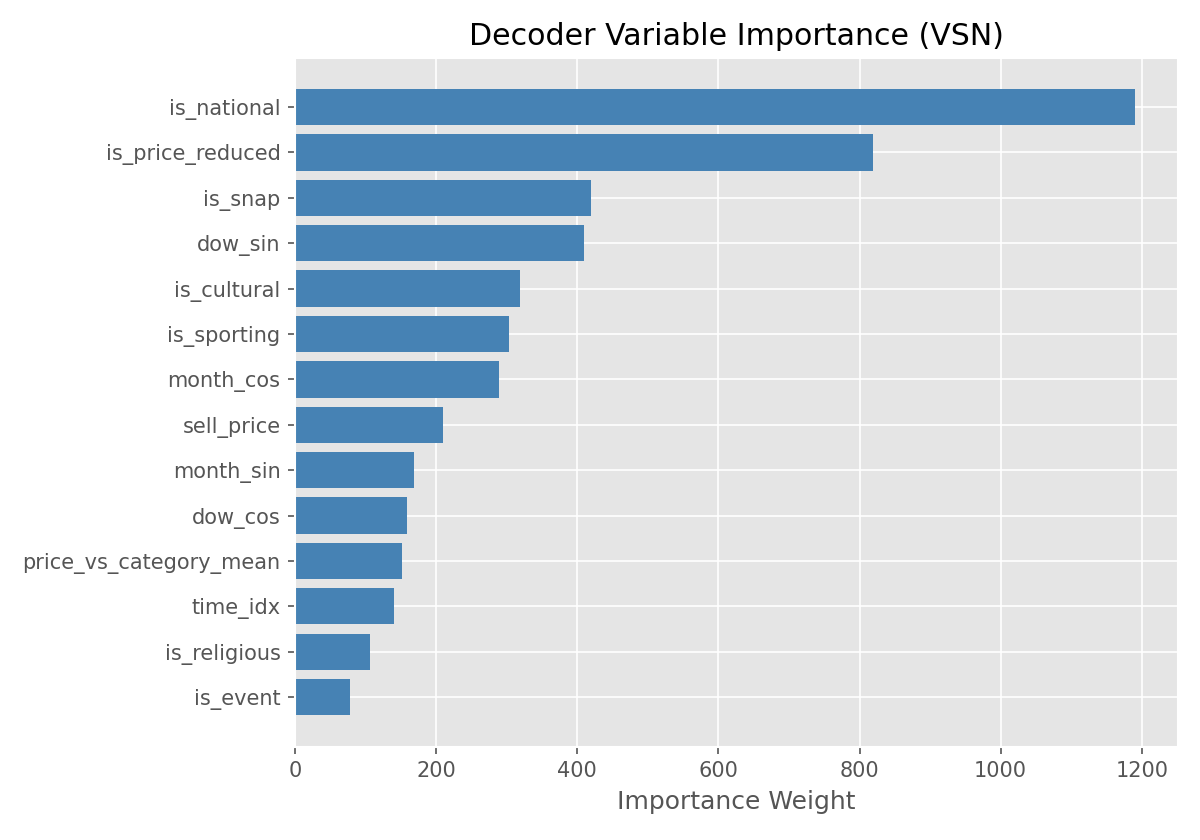

### Attention heatmap

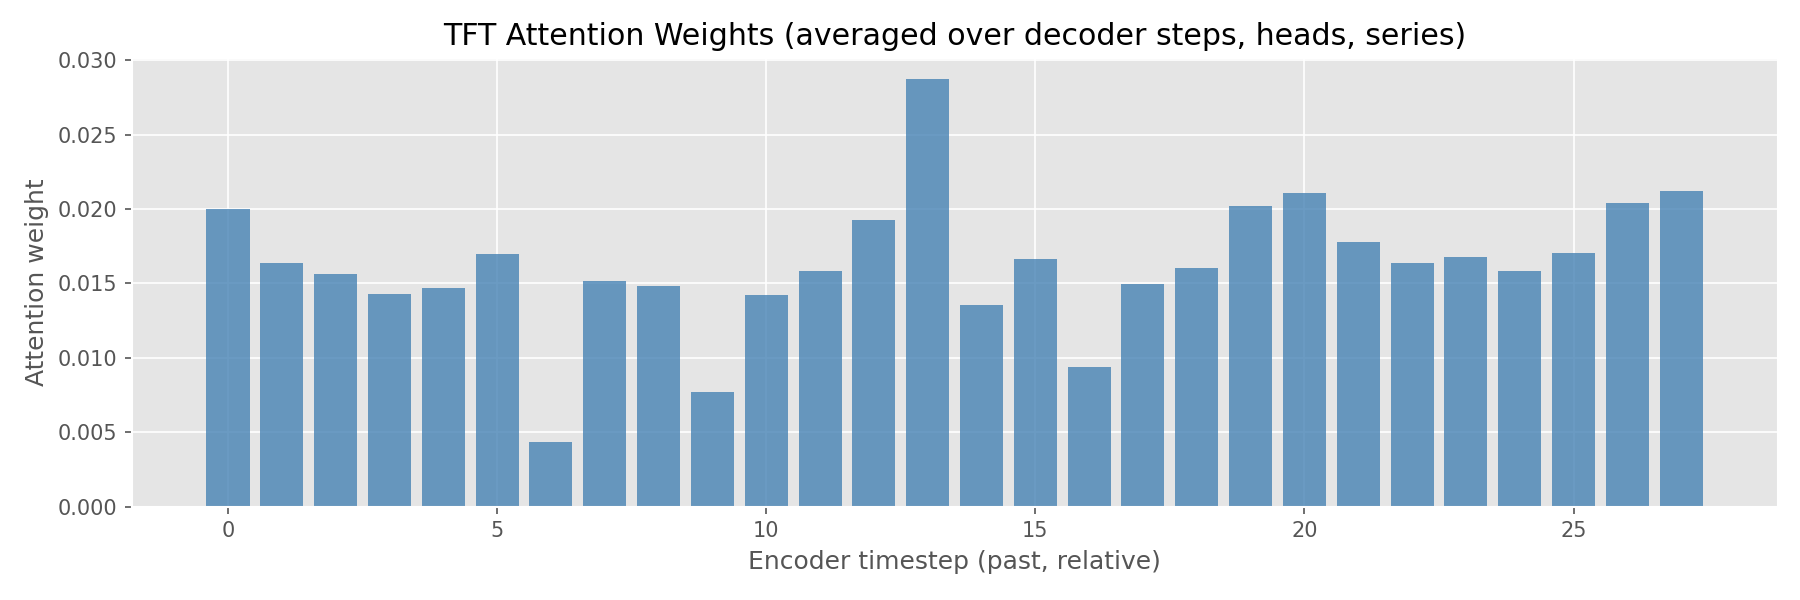

In [16]:
interpretability_files = [
    ('Static variable importance', FIGS_DIR / 'tft_static_importance.png'),
    ('Encoder variable importance', FIGS_DIR / 'tft_encoder_importance.png'),
    ('Decoder variable importance', FIGS_DIR / 'tft_decoder_importance.png'),
    ('Attention heatmap', FIGS_DIR / 'tft_attention_heatmap.png'),
]

for title, path in interpretability_files:
    if path.exists():
        display(Markdown(f'### {title}'))
        display(Image(filename=str(path), width=900))
    else:
        print('Missing:', path)


## 9. 28-Day Inference: Predicted vs Expected

This section is meant for the final presentation/demo slide.

It shows a concrete 28-day forecast for all four model families:

- ARIMA/SARIMA: classical baseline sample
- LSTM: deep point-forecast baseline
- Informer: transformer point-forecast baseline
- TFT: `p50` median forecast, with `p10-p90` uncertainty band

Here, **Expected** means the actual observed sales in the 28-day test horizon, and **Predicted** means the model forecast. For TFT, **Predicted** is the `p50` median quantile; its `p10-p90` interval is shown as the uncertainty band.


In [17]:
INFERENCE_MODELS = ['ARIMA', 'LSTM', 'Informer', 'TFT']


def choose_single_inference_id(df, target_quantile=0.75):
    """Pick a readable representative series, not the largest spike-heavy item."""
    stats = df.groupby('id')['actual'].agg(['sum', 'max']).reset_index()
    stats = stats[stats['sum'] > 0].copy()
    if stats.empty:
        return df['id'].iloc[0]
    target = stats['sum'].quantile(target_quantile)
    stats['distance_to_target'] = (stats['sum'] - target).abs()
    return stats.sort_values(['distance_to_target', 'max']).iloc[0]['id']


# ARIMA uses its own classical baseline sample. Deep models share the same aligned benchmark series.
arima_inference_id = choose_single_inference_id(preds[('ARIMA', 'Test')], target_quantile=0.75)
deep_inference_id = choose_single_inference_id(preds[('LSTM', 'Test')], target_quantile=0.75)
selected_inference_ids = {
    'ARIMA': arima_inference_id,
    'LSTM': deep_inference_id,
    'Informer': deep_inference_id,
    'TFT': deep_inference_id,
}

inference_rows = []
for model in INFERENCE_MODELS:
    df = preds[(model, 'Test')].copy().sort_values(['id', 'date'])
    series_id = selected_inference_ids[model]
    g = df[df['id'] == series_id].sort_values('date').head(28).copy()
    g['Forecast Day'] = np.arange(1, len(g) + 1)
    g['Model'] = model
    g['Series ID'] = series_id
    g['Expected'] = g['actual'].round(4)
    g['Predicted'] = g['predicted'].round(4)
    g['Error'] = (g['predicted'] - g['actual']).round(4)
    g['Lower P10'] = g['p10'].clip(lower=0).round(4) if 'p10' in g.columns else np.nan
    g['Upper P90'] = g['p90'].clip(lower=0).round(4) if 'p90' in g.columns else np.nan
    inference_rows.append(g[['Model', 'Series ID', 'Forecast Day', 'date', 'Expected', 'Predicted', 'Error', 'Lower P10', 'Upper P90']])

inference_examples = pd.concat(inference_rows, ignore_index=True)
inference_examples = inference_examples.rename(columns={'date': 'Date'})
inference_examples.to_csv(PREDS_DIR / 'presentation_28day_inference_examples.csv', index=False)

print('Selected inference examples:')
for model, series_id in selected_inference_ids.items():
    role = 'classical baseline sample' if model == 'ARIMA' else 'aligned deep-model benchmark'
    print(f'  {model}: {series_id} ({role})')

display(inference_examples)
print('Saved:', PREDS_DIR / 'presentation_28day_inference_examples.csv')


Selected inference examples:
  ARIMA: FOODS_3_615_CA_1_evaluation (classical baseline sample)
  LSTM: HOUSEHOLD_1_213_TX_2_evaluation (aligned deep-model benchmark)
  Informer: HOUSEHOLD_1_213_TX_2_evaluation (aligned deep-model benchmark)
  TFT: HOUSEHOLD_1_213_TX_2_evaluation (aligned deep-model benchmark)


,Model,Series ID,Forecast Day,Date,Expected,Predicted,Error,Lower P10,Upper P90
0,ARIMA,FOODS_3_615_CA_1_evaluation,1,2016-04-25,2.0,2.1569,0.1569,NaN,NaN
1,ARIMA,FOODS_3_615_CA_1_evaluation,2,2016-04-26,4.0,2.4298,-1.5702,NaN,NaN
2,ARIMA,FOODS_3_615_CA_1_evaluation,3,2016-04-27,0.0,2.4476,2.4476,NaN,NaN
3,ARIMA,FOODS_3_615_CA_1_evaluation,4,2016-04-28,3.0,2.2268,-0.7732,NaN,NaN
4,ARIMA,FOODS_3_615_CA_1_evaluation,5,2016-04-29,4.0,2.3967,-1.6033,NaN,NaN
...,...,...,...,...,...,...,...,...,...
107,TFT,HOUSEHOLD_1_213_TX_2_evaluation,24,2016-05-18,0.0,0.0270,0.0270,0.0000,3.1349
108,TFT,HOUSEHOLD_1_213_TX_2_evaluation,25,2016-05-19,1.0,0.0218,-0.9782,0.0000,3.1403
109,TFT,HOUSEHOLD_1_213_TX_2_evaluation,26,2016-05-20,1.0,0.0238,-0.9762,0.0000,3.1248
110,TFT,HOUSEHOLD_1_213_TX_2_evaluation,27,2016-05-21,3.0,0.0673,-2.9327,0.0001,3.5641


Saved: ../outputs/predictions/presentation_28day_inference_examples.csv


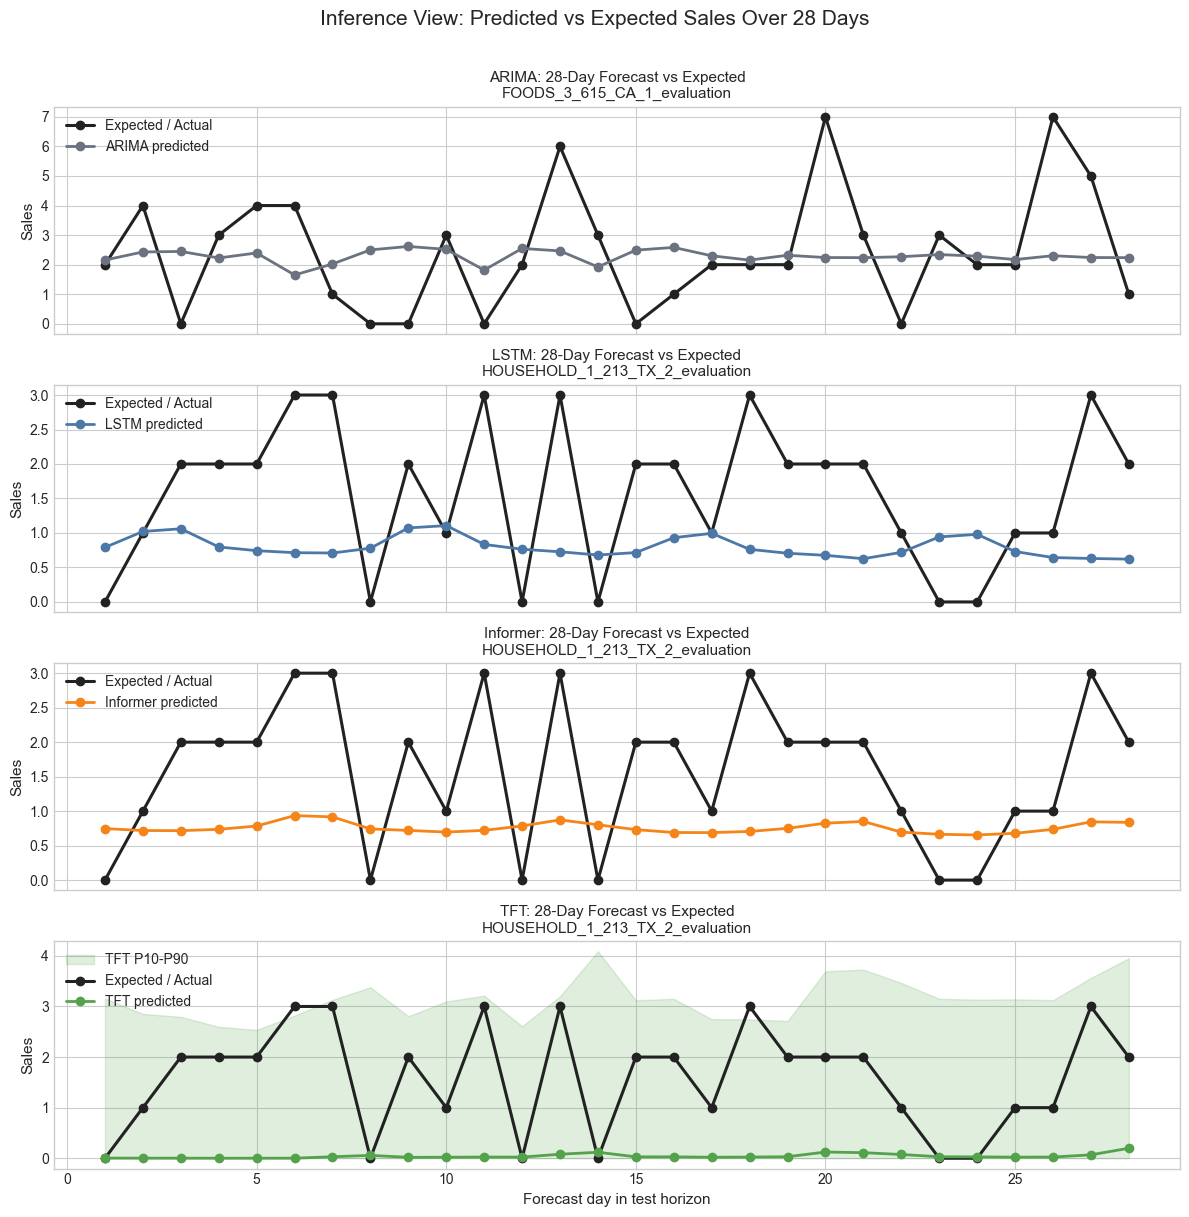

Saved: ../outputs/figures/presentation_28day_inference_predicted_vs_expected.png


In [18]:
fig, axes = plt.subplots(len(INFERENCE_MODELS), 1, figsize=(12, 3.0 * len(INFERENCE_MODELS)), sharex=True)
axes = np.atleast_1d(axes).ravel()
for ax, model in zip(axes, INFERENCE_MODELS):
    g = inference_examples[inference_examples['Model'] == model]
    x = g['Forecast Day'].to_numpy()
    if model == 'TFT' and g['Lower P10'].notna().any() and g['Upper P90'].notna().any():
        ax.fill_between(x, g['Lower P10'].to_numpy(), g['Upper P90'].to_numpy(), color=COLORS['TFT'], alpha=0.18, label='TFT P10-P90')
    ax.plot(x, g['Expected'], marker='o', linewidth=2.2, color=COLORS['Actual'], label='Expected / Actual')
    ax.plot(x, g['Predicted'], marker='o', linewidth=2.0, color=COLORS.get(model, '#6B7280'), label=f'{model} predicted')
    ax.set_title(f'{model}: 28-Day Forecast vs Expected\n{g["Series ID"].iloc[0]}', fontsize=11)
    ax.set_ylabel('Sales')
    ax.legend(loc='upper left')

axes[-1].set_xlabel('Forecast day in test horizon')
fig.suptitle('Inference View: Predicted vs Expected Sales Over 28 Days', y=1.01, fontsize=15)
fig.tight_layout()
out = FIGS_DIR / 'presentation_28day_inference_predicted_vs_expected.png'
fig.savefig(out, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', out)


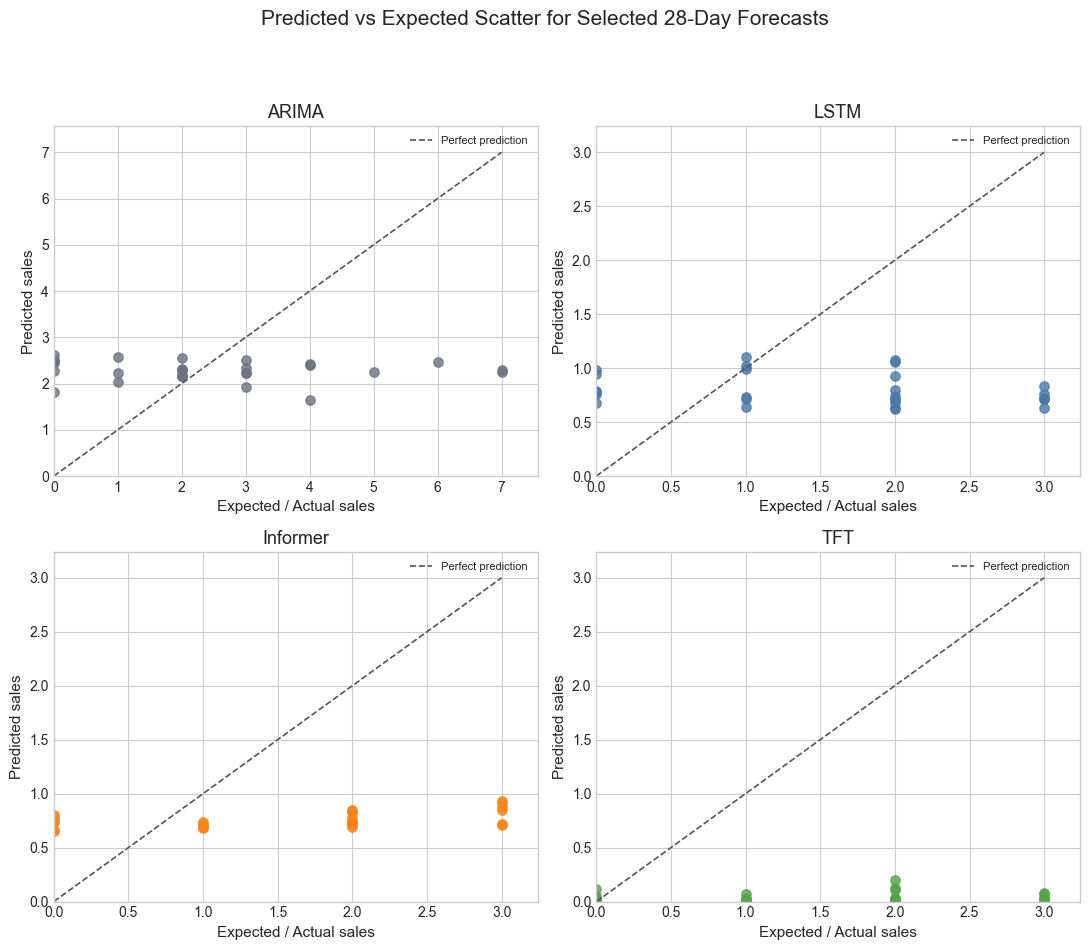

Saved: ../outputs/figures/presentation_28day_inference_scatter.png


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=False, sharey=False)
axes = axes.ravel()
for ax, model in zip(axes, INFERENCE_MODELS):
    g = inference_examples[inference_examples['Model'] == model]
    ax.scatter(g['Expected'], g['Predicted'], s=45, alpha=0.8, color=COLORS.get(model, '#6B7280'))
    lim_max = max(float(g['Expected'].max()), float(g['Predicted'].max()), 1.0)
    ax.plot([0, lim_max], [0, lim_max], color='#555555', linestyle='--', linewidth=1.2, label='Perfect prediction')
    ax.set_title(model)
    ax.set_xlabel('Expected / Actual sales')
    ax.set_ylabel('Predicted sales')
    ax.set_xlim(0, lim_max * 1.08)
    ax.set_ylim(0, lim_max * 1.08)
    ax.legend(fontsize=8)

fig.suptitle('Predicted vs Expected Scatter for Selected 28-Day Forecasts', y=1.05, fontsize=15)
fig.tight_layout()
out = FIGS_DIR / 'presentation_28day_inference_scatter.png'
fig.savefig(out, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', out)
